# Look-Ahead-Bias — free alpha from peeking one bar ahead 🔮
### The most expensive missing line of code in quant finance: `.shift(1)`

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_one--bar_peek_inflates_the_backtest%3F: Confirmed](https://img.shields.io/badge/A_one--bar_peek_inflates_the_backtest%3F-Confirmed-8b949e?style=flat-square)

Imagine a backtest that lets you *act on today's closing price using today's closing price* — buy at the open knowing how the day ends. Sounds absurd, but it's a one-character bug away in every backtest: forget to push your signal forward one bar, and a nothing strategy turns into a Sharpe-5 superstar. This notebook plants that bug on purpose and measures exactly how much free alpha it invents.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the bootstrap and the sign-flip proof? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from look_ahead_bias import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE, "SPY"))

HAVE_REAL = _have_cache()

def real_tape():
    s = data.load_real("SPY", fetch=False)
    # drop the in-progress final month (as-of = last full month).
    asof = pd.Timestamp.today().normalize().to_period("M").to_timestamp() - pd.Timedelta(days=1)
    return s[s.index <= asof]

print("real SPY cache present:", HAVE_REAL)


real SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| How much does a one-bar peek help? | **It manufactures a Sharpe of ~5 from nothing.** On real SPY a momentum rule with *no* real edge jumps to Sharpe **4.9** the instant it earns its own bar. |
| Is any of it real? | **No.** Trade the same signal honestly (one bar later) and the Sharpe is **-0.14** — a coin flip. The 'edge' was the signal correlating with the data that defined it. |
| Can't trading costs catch it? | **No — and that's the scary part.** The fake Sharpe barely moves with costs, because a peek isn't an edge you trade, it's an accounting tautology. |
| What's the fix? | **One line.** Push every signal forward one bar before it earns a return — the desk's *one-execution-lag* rule. |

> A look-ahead backtest looks *beautiful and robust* — high Sharpe, cheap to trade. Both are illusions. That's exactly why it fools people.

## 1 · The claim

Nobody *claims* look-ahead bias is good — they ship it by accident. The claim we're steelmanning is the seductive backtest it produces: *"I built a simple momentum rule and it has a Sharpe near 5 — it must be a real edge, look how stable it is even after costs."* This is backtesting **sin #1** in López de Prado's *Advances in Financial Machine Learning* and Deutsche Bank's *Seven Sins of Quantitative Investing*: the single most common way a paper Sharpe turns out to be fiction. The strong version of the trap is that the result looks *more* convincing than a real edge — higher Sharpe, more significant, cost-proof — so it survives exactly the checks people trust.

## 2 · So what?

A real edge and a look-ahead artefact are worth opposite amounts: one is a business, the other loses you money the day you go live. Worse, the artefact is *persuasive* — it sails through cost sweeps and significance tests. If you can't tell them apart at the desk, you will fund the mirage and starve the edge. The stakes here aren't one strategy; they're whether your whole research process can be trusted. The fix costs one line of code — but only if you know to look for it.

## 3 · How would we even know?

We run **one** ordinary signal — a 20-day momentum rule (lean long when the price is above its recent average) — two ways on the *same* prices:

1. **peek** — the position decided at today's close earns *today's* return (the bar that produced the signal). The bug.
2. **lag1** — the position decided at today's close earns *tomorrow's* return. The only version a human can actually trade.

Then we look at three tapes: a **random walk** (no edge exists — anything the peek finds is pure bias), a **planted-edge** synthetic market (to prove our machine *can* find a real, fairly-tradable edge), and **real SPY**. If the peek lights up where the honest lag is dark, we've caught the bias red-handed.

## 4 · The teardown — let's actually look

**First, the cleanest case: a coin-flip market.** We build a pure random walk — by construction there is *nothing to predict*. Watch what the peek does to the same momentum rule the honest lag finds worthless:

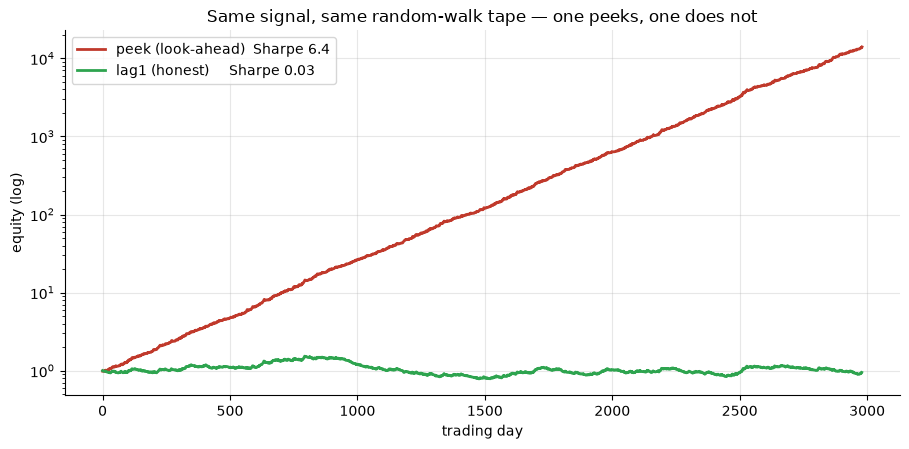

peek Sharpe 6.36 | lag1 Sharpe 0.03 | inflation 6.32


In [2]:
p, _ = data.synthetic_prices(n_days=3000, edge=0.0, seed=347)
res = st.compare(p, signal='momentum', cost_bps=0.0)
eq_peek = (1+res['peek']).cumprod()
eq_lag1 = (1+res['lag1']).cumprod()
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.plot(eq_peek.values, c=RED, lw=2, label=f"peek (look-ahead)  Sharpe {res['summary_peek']['sharpe']:.1f}")
ax.plot(eq_lag1.values, c=GREEN, lw=2, label=f"lag1 (honest)     Sharpe {res['summary_lag1']['sharpe']:.2f}")
ax.set_yscale('log'); ax.set_xlabel('trading day'); ax.set_ylabel('equity (log)')
ax.set_title('Same signal, same random-walk tape — one peeks, one does not')
ax.legend(); plt.tight_layout(); plt.show()
print(f"peek Sharpe {res['summary_peek']['sharpe']:.2f} | lag1 Sharpe {res['summary_lag1']['sharpe']:.2f} | inflation {res['sharpe_inflation']:.2f}")

On a market with **zero** predictability, the honest rule earns nothing (a flat line, Sharpe ~0) while the peek rockets up a smooth exponential. Every cent of that curve is the look-ahead bias. It isn't finding a pattern — it's letting the signal grade its own homework.

**Now the real tape.** Twenty years of SPY. Does the same trick work on real prices?

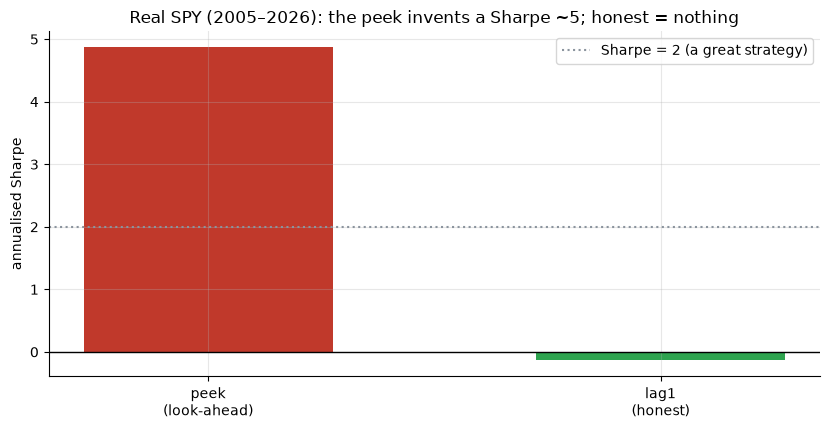

peek Sharpe 4.87 vs honest -0.14


In [3]:
if HAVE_REAL:
    s = real_tape()
    rr = st.compare(s, signal='momentum', cost_bps=0.0)
    sharpes = [rr['summary_peek']['sharpe'], rr['summary_lag1']['sharpe']]
else:
    sharpes = [4.87, -0.14]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
b = ax.bar(['peek\n(look-ahead)', 'lag1\n(honest)'], sharpes, color=[RED, GREEN], width=.55)
ax.axhline(0, c='k', lw=1); ax.axhline(2, ls=':', c=GREY, label='Sharpe = 2 (a great strategy)')
ax.set_ylabel('annualised Sharpe'); ax.legend()
ax.set_title('Real SPY (2005–2026): the peek invents a Sharpe ~5; honest = nothing')
plt.tight_layout(); plt.show()
print(f'peek Sharpe {sharpes[0]:.2f} vs honest {sharpes[1]:.2f}')

On real SPY the peek prints Sharpe **4.9** — better than almost any real strategy ever published — while the honest, tradable version of the *exact same rule* sits at **-0.14**, indistinguishable from zero. There is no momentum edge here; there is only the bias.

**"But surely trading costs kill it?"** This is the trap. Costs kill *real* thin edges. A look-ahead artefact isn't an edge — so costs barely scratch it:

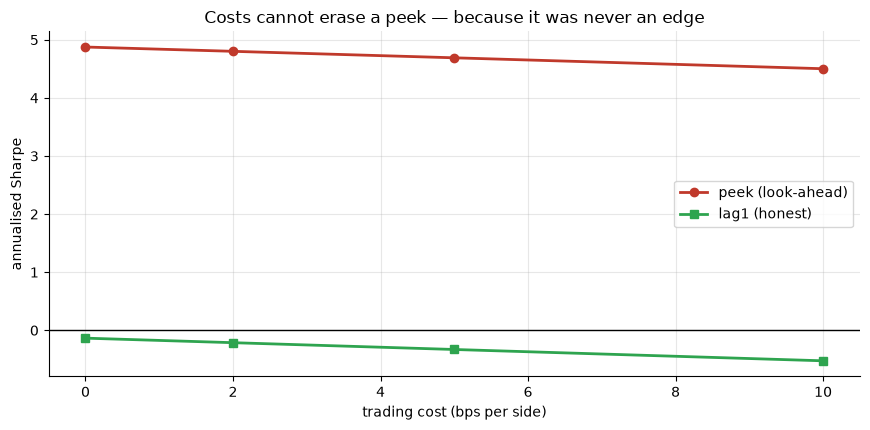

peek Sharpe by cost: ['4.87', '4.80', '4.69', '4.50']


In [4]:
if HAVE_REAL:
    costs = [0.0, 2.0, 5.0, 10.0]
    peek_s = [st.compare(s, signal='momentum', cost_bps=c)['summary_peek']['sharpe'] for c in costs]
    lag1_s = [st.compare(s, signal='momentum', cost_bps=c)['summary_lag1']['sharpe'] for c in costs]
else:
    costs = [0.0, 2.0, 5.0, 10.0]
    peek_s = [4.87, 4.80, 4.69, 4.50]
    lag1_s = [-0.14, -0.21, -0.33, -0.53]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.plot(costs, peek_s, 'o-', c=RED, lw=2, label='peek (look-ahead)')
ax.plot(costs, lag1_s, 's-', c=GREEN, lw=2, label='lag1 (honest)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('trading cost (bps per side)'); ax.set_ylabel('annualised Sharpe')
ax.set_title('Costs cannot erase a peek — because it was never an edge'); ax.legend()
plt.tight_layout(); plt.show()
print('peek Sharpe by cost:', [f'{x:.2f}' for x in peek_s])

The honest line wanders around zero; the peek line stays sky-high across the whole cost sweep. **The very 'robustness' that makes a look-ahead backtest convincing is the proof it's fake** — a real edge bleeds out under costs; a tautology doesn't.

## 5 · The verdict

- **Signal — None.** Traded honestly, the rule has no edge (Sharpe -0.14). The whole headline was an artefact.
- **Tradability — Mirage.** The Sharpe-5 'strategy' needs you to fill on a close that hasn't happened. Nobody can trade it, at any price.
- **Does a one-bar peek inflate the backtest? — Confirmed.** A zero-edge rule becomes Sharpe **4.9** on real SPY, cost-proof, the moment the signal earns its own bar. The fix is one `shift`.

## 6 · Could you actually trade it?

No — and that's the entire point. To 'trade' the peek you'd have to know each day's closing price *before* it prints and act on it at that same close. That's not a hard execution problem; it's time travel. The honest version of the rule is fully tradable and earns nothing. So the only real takeaway is defensive: **before you believe any backtest, find the line that shifts the signal forward one bar.** If it isn't there, the Sharpe on the page is measuring the future leaking into the past — not an edge you can keep.

## 7 · Going further 🚪

- **Other peeks.** This is the close-to-close version. Intraday, the same bug hides as 'enter at the open using the day's high/low', or 'rebalance on month-end data you only got days later'. Fork this and plant those.
- **Restated data.** Fundamentals get *revised*; using the final number instead of the as-first-reported one is look-ahead too (Sloan 1996). A point-in-time version of this study is a natural next step.
- **The deep version.** The companion [02_for_the_quants.ipynb](02_for_the_quants.ipynb) proves the bias is *contemporaneous correlation* (flip the signal, the fake Sharpe flips sign) and shows the harness banks a real planted edge only with the correct lag.

*Think your favourite backtest is clean? Fork this, drop your signal in, and run it peek vs lag1. If the two look different, you've found a bug — or an edge. Only the lag tells you which.*